학습 시작...
Epoch [20/2000], Loss: 0.127275
Epoch [40/2000], Loss: 0.054742
Epoch [60/2000], Loss: 0.036467
Epoch [80/2000], Loss: 0.026950
Epoch [100/2000], Loss: 0.020671
Epoch [120/2000], Loss: 0.016209
Epoch [140/2000], Loss: 0.012944
Epoch [160/2000], Loss: 0.010527
Epoch [180/2000], Loss: 0.008733
Epoch [200/2000], Loss: 0.007419
Epoch [220/2000], Loss: 0.006485
Epoch [240/2000], Loss: 0.005866
Epoch [260/2000], Loss: 0.005501
Epoch [280/2000], Loss: 0.005321
Epoch [300/2000], Loss: 0.005243
Epoch [320/2000], Loss: 0.005205
Epoch [340/2000], Loss: 0.005177
Epoch [360/2000], Loss: 0.005151
Epoch [380/2000], Loss: 0.005126
Epoch [400/2000], Loss: 0.005102
Epoch [420/2000], Loss: 0.005079
Epoch [440/2000], Loss: 0.005057
Epoch [460/2000], Loss: 0.005036
Epoch [480/2000], Loss: 0.005016
Epoch [500/2000], Loss: 0.004998
Epoch [520/2000], Loss: 0.004980
Epoch [540/2000], Loss: 0.004964
Epoch [560/2000], Loss: 0.004949
Epoch [580/2000], Loss: 0.004934
Epoch [600/2000], Loss: 0.004921
Epoch

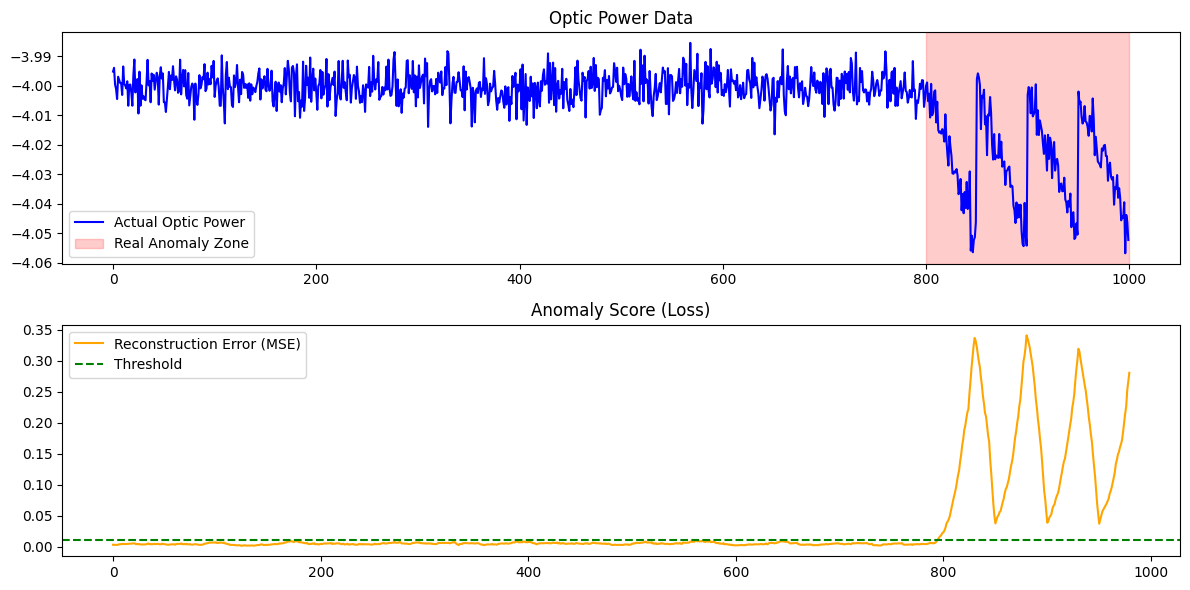

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 데이터를 0~1 사이로 압축 (정규화)
def normalize(data):
  min_val = np.min(data)
  max_val = np.max(data)
  return (data - min_val) / (max_val - min_val), min_val, max_val

# 1. 더미 데이터 생성 (정상 패턴 800개, 이상 패턴 200개)
def generate_data():
  t = np.linspace(0, 100, 1000)
# 정상: -4dBm 기준 미세 노이즈
  normal_data = -4 + np.random.normal(0, 0.005, 800)
  # normal_data = -4 + np.sin(t[:800]) * 0.05 + np.random.normal(0, 0.005, 800)
# 이상: 서서히 급격히 하락하는 패턴
  anomaly_data = -4 - np.linspace(0, 0.05, 50) + np.random.normal(0, 0.005, 50)
  anomaly_data2 = -4.05 + np.linspace(0, 0.05, 50) + np.random.normal(0, 0.005, 50)
  anomaly_data3 = -4 - np.linspace(0, 0.05, 50) + np.random.normal(0, 0.005, 50)
  anomaly_data4 = -4 - np.linspace(0, 0.05, 50) + np.random.normal(0, 0.005, 50)
  full_data = np.concatenate([normal_data, anomaly_data, anomaly_data2, anomaly_data3, anomaly_data4])
  return full_data.reshape(-1, 1)

 # 시계열 데이터를 일정한 길이(Window Size)의 묶음으로 변환
def create_sequences(data, window_size):
  sequences = []
  for i in range(len(data) - window_size):
    sequences.append(data[i:i+window_size])
  return torch.FloatTensor(np.array(sequences))

WINDOW_SIZE = 20  # 20개씩 묶어서 패턴을 학습
raw_data_origin = generate_data()
raw_data, min_v, max_v = normalize(raw_data_origin)
train_data = create_sequences(raw_data[:800], WINDOW_SIZE)
full_data = create_sequences(raw_data, WINDOW_SIZE)

# 2. LSTM Autoencoder 모델 정의
class LSTMAutoencoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, window_size):
    super(LSTMAutoencoder, self).__init__()
    self.window_size = window_size
    self.hidden_dim = hidden_dim
    # Encoder: 입력 시퀀스를 압축
    self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
    # Decoder: 압축된 정보를 다시 복원
    self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

  def forward(self, x):
    # Encoder: 입력 시퀀스 -> 특징 추출 (마지막 hidden state 사용)
    _, (hidden, _) = self.encoder(x)
    # Decoder: 특징 -> 원래 시퀀스로 복원
    # hidden state를 WINDOW_SIZE만큼 반복해서 입력으로 넣어줌
    repeat_hidden = hidden.permute(1, 0, 2).expand(-1, self.window_size, -1)
    x_rev, _ = self.decoder(repeat_hidden)
    return x_rev

# 3. 모델 설정 및 학습
model = LSTMAutoencoder(input_dim=1, hidden_dim=16, window_size=WINDOW_SIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 2000
model.train()
print("학습 시작...")

for epoch in range(EPOCHS):
   optimizer.zero_grad()               # 기울기 초기화
   output = model(train_data)          # 모델의 예측 (복원 시도)
   loss = criterion(output, train_data) # 원본과 복원값의 차이 계산
   loss.backward()                     # 역전파 (오차를 모델에 전달)
   optimizer.step()                    # 가중치 업데이트

   if (epoch+1) % 20 == 0:
      print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.6f}")

print("학습 완료!")

# 4. 이상 탐지 테스트
model.eval()
with torch.no_grad():
  # 전체 데이터(정상+이상)를 모델에 넣어 복원 오차 확인
  predictions = model(full_data)
  # 각 시퀀스별 MSE 오차 계산
  mse_errors = torch.mean((predictions - full_data)**2, dim=(1, 2)).numpy()

# 5. 시각화
plt.figure(figsize=(12, 6))

# 5-1. 원본 데이터 시각화
plt.subplot(2, 1, 1)
plt.plot(raw_data_origin, label='Actual Optic Power', color='blue')
plt.axvspan(800, 1000, color='red', alpha=0.2, label='Real Anomaly Zone')
plt.title("Optic Power Data")
plt.legend()

# 5-2. 복원 오차 시각화 (이 오차가 튀는 지점이 AI가 '이상하다'고 느끼는 지점)
plt.subplot(2, 1, 2)
plt.plot(mse_errors, label='Reconstruction Error (MSE)', color='orange')
plt.axhline(y=0.01, color='green', linestyle='--', label='Threshold') # 임계치 예시
plt.title("Anomaly Score (Loss)")
plt.legend()

plt.tight_layout()
plt.show()


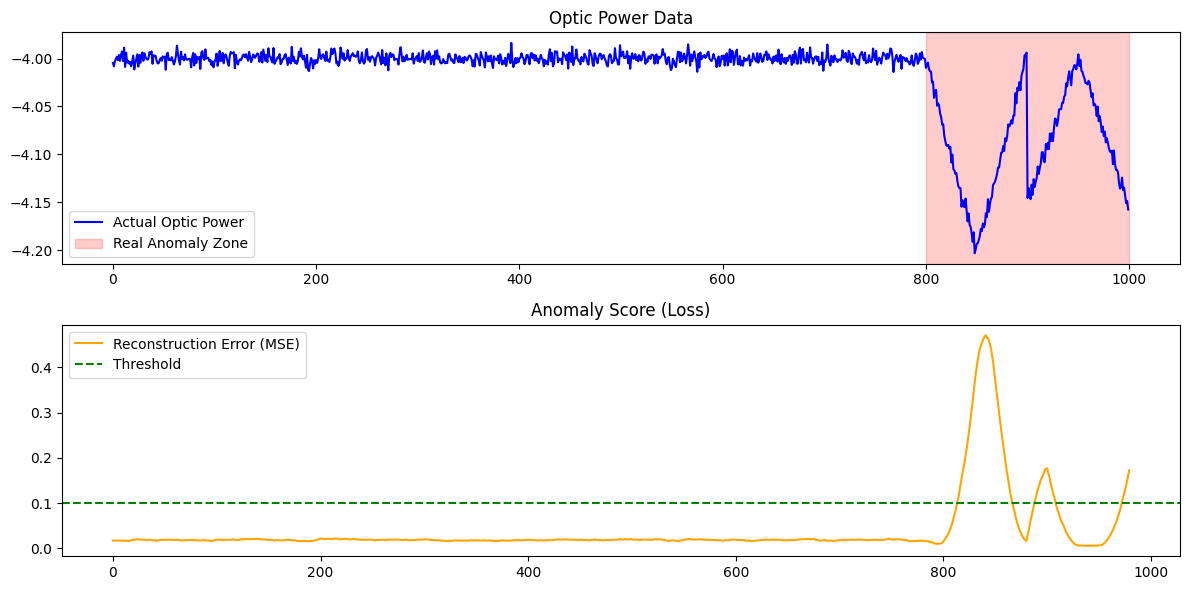

In [ ]:
# 1. 더미 데이터 생성 (정상 패턴 800개, 이상 패턴 200개)
def generate_data():
  t = np.linspace(0, 100, 1000)
# 정상: -4dBm 기준 미세 노이즈
  normal_data = -4 + np.random.normal(0, 0.005, 800)
  # normal_data = -4 + np.sin(t[:800]) * 0.05 + np.random.normal(0, 0.005, 800)
# 이상: 서서히 급격히 하락하는 패턴
  anomaly_data = -4 - np.linspace(0, 0.2, 50) + np.random.normal(0, 0.005, 50)
  anomaly_data2 = -4.2 + np.linspace(0, 0.2, 50) + np.random.normal(0, 0.005, 50)
  anomaly_data3 = -4.15 + np.linspace(0, 0.15, 50) + np.random.normal(0, 0.005, 50)
  anomaly_data4 = -4 - np.linspace(0, 0.15, 50) + np.random.normal(0, 0.005, 50)
  full_data = np.concatenate([normal_data, anomaly_data, anomaly_data2, anomaly_data3, anomaly_data4])
  return full_data.reshape(-1, 1)

 # 시계열 데이터를 일정한 길이(Window Size)의 묶음으로 변환
def create_sequences(data, window_size):
  sequences = []
  for i in range(len(data) - window_size):
    sequences.append(data[i:i+window_size])
  return torch.FloatTensor(np.array(sequences))

WINDOW_SIZE = 20  # 20개씩 묶어서 패턴을 학습
raw_data_origin = generate_data()
raw_data, min_v, max_v = normalize(raw_data_origin)
train_data = create_sequences(raw_data[:800], WINDOW_SIZE)
full_data = create_sequences(raw_data, WINDOW_SIZE)

# 4. 이상 탐지 테스트
model.eval()
with torch.no_grad():
  # 전체 데이터(정상+이상)를 모델에 넣어 복원 오차 확인
  predictions = model(full_data)
  # 각 시퀀스별 MSE 오차 계산
  mse_errors = torch.mean((predictions - full_data)**2, dim=(1, 2)).numpy()

# 5. 시각화
plt.figure(figsize=(12, 6))

# 5-1. 원본 데이터 시각화
plt.subplot(2, 1, 1)
plt.plot(raw_data_origin, label='Actual Optic Power', color='blue')
plt.axvspan(800, 1000, color='red', alpha=0.2, label='Real Anomaly Zone')
plt.title("Optic Power Data")
plt.legend()

# 5-2. 복원 오차 시각화 (이 오차가 튀는 지점이 AI가 '이상하다'고 느끼는 지점)
plt.subplot(2, 1, 2)
plt.plot(mse_errors, label='Reconstruction Error (MSE)', color='orange')
plt.axhline(y=0.1, color='green', linestyle='--', label='Threshold') # 임계치 예시
plt.title("Anomaly Score (Loss)")
plt.legend()

plt.tight_layout()
plt.show()